In [1]:
import os

os.chdir(os.path.expanduser('~/magisterka'))
print("Working directory:", os.getcwd())

Working directory: /Users/robertpilczuk/magisterka


Przygotowanie danych (Preprocessing)
Cel tego notebooka
Algorytm regresji liniowej operuje wyłącznie na liczbach. Surowe dane zawierają
tekst (gatunki, płeć), kategorie (zawód) i różne skale liczbowe.
Preprocessing zamienia wszystkie informacje na reprezentację numeryczną
gotową do trenowania modelu.

📄 Szczegółowe wyjaśnienie każdego kroku i uzasadnienie wyborów: docs/02_preprocessing.md

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
import os

df = pd.read_csv('data/merged_raw.csv')
print(f"Wczytano: {df.shape}")
display(df.head(3))

Wczytano: (1000209, 11)


,userId,movieId,rating,timestamp,gender,age,occupation,zip,age_label,title,genres
0,1,1193,5,978300760,F,1,10,48067,<18,One Flew Over the Cuckoo's Nest (1975),Drama
1,1,661,3,978302109,F,1,10,48067,<18,James and the Giant Peach (1996),Animation|Children's|Musical
2,1,914,3,978301968,F,1,10,48067,<18,My Fair Lady (1964),Musical|Romance


Ekstrakcja roku produkcji
Tytuły filmów zawierają rok w nawiasie: "Toy Story (1995)".
Używamy wyrażenia regularnego (regex) żeby wyciągnąć rok jako osobną
zmienną numeryczną. Rok może być istotnym predyktorem — filmy z różnych
epok są oceniane przez różne grupy widzów.

In [3]:
df['year'] = df['title'].str.extract(r'\((\d{4})\)').astype(float)

print("Brakujące lata:", df['year'].isna().sum())
print(df[['title', 'year']].head(5))

Brakujące lata: 0
                                    title    year
0  One Flew Over the Cuckoo's Nest (1975)  1975.0
1        James and the Giant Peach (1996)  1996.0
2                     My Fair Lady (1964)  1964.0
3                  Erin Brockovich (2000)  2000.0
4                    Bug's Life, A (1998)  1998.0


Enkodowanie płci
Kolumna gender zawiera tekst (M/F) — zamieniamy na liczby binarne:

M (mężczyzna) → 0
F (kobieta) → 1

Kodowanie binarne (0/1) jest właściwe dla zmiennych z dokładnie dwiema
kategoriami. Użycie 1/2 sugerowałoby błędnie że jedna kategoria jest
"dwa razy większa" od drugiej.

In [4]:
df['gender_encoded'] = (df['gender'] == 'M').astype(int)
print(df[['gender', 'gender_encoded']].value_counts())

gender  gender_encoded
M       1                 753769
F       0                 246440
Name: count, dtype: int64


One-Hot Encoding gatunków
Jeden film może należeć do wielu gatunków ("Action|Sci-Fi|Thriller").
One-Hot Encoding tworzy osobną kolumnę binarną dla każdego gatunku:
1 = film należy do gatunku, 0 = nie należy.
MovieLens 1M zawiera 18 gatunków → powstaje 18 nowych kolumn binarnych.

📄 Dlaczego nie kodujemy gatunków jako liczb (1=Action, 2=Comedy...)? docs/02_preprocessing.md → sekcja "Celka 4"

In [5]:
genres_dummies = df['genres'].str.get_dummies(sep='|')
print("Gatunki:", genres_dummies.columns.tolist())
print("Shape:", genres_dummies.shape)
df = pd.concat([df, genres_dummies], axis=1)

Gatunki: ['Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
Shape: (1000209, 18)


One-Hot Encoding zawodów
Zawód jest zakodowany jako liczba 0–20, ale nie ma wartości numerycznej
(zawód nr 12 nie jest "większy" niż zawód nr 3) — stosujemy One-Hot Encoding.
Powstaje 21 kolumn binarnych (occ_0 ... occ_20).
Hipoteza: zawód może korelować z preferencjami filmowymi —
np. programiści mogą preferować Sci-Fi, artyści — filmy dokumentalne.

In [6]:
occupation_dummies = pd.get_dummies(df['occupation'], prefix='occ')
print("Zawody (kolumny):", occupation_dummies.shape[1])
df = pd.concat([df, occupation_dummies], axis=1)

Zawody (kolumny): 21


Cechy agregowane
Tworzymy trzy zmienne wyliczane z historii ocen:

user_avg_rating — średnia ocen użytkownika: czy jest wymagający czy łagodny? (tzw. user bias)
movie_avg_rating — średnia ocen filmu: jak bardzo jest ceniony przez wszystkich? (tzw. item bias)
movie_rating_count — liczba ocen filmu: jak popularne i "wiarygodne" są jego statystyki?

To jedne z najważniejszych zmiennych w modelu.

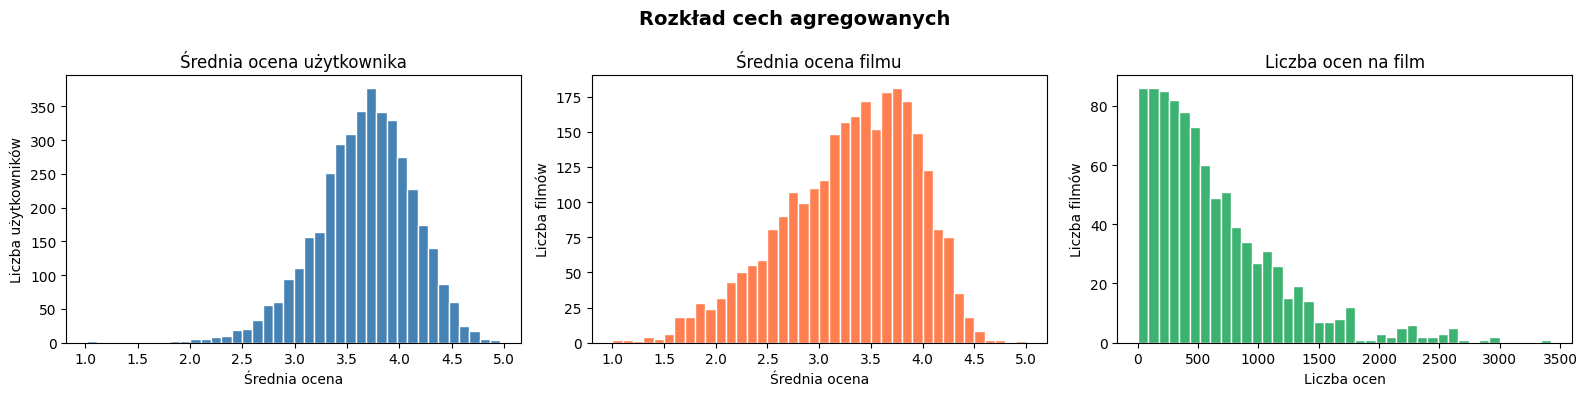

In [7]:
import matplotlib.pyplot as plt

# usuń kolumny jeśli już istnieją (zabezpieczenie przed ponownym uruchomieniem)
for col in ['user_avg_rating', 'movie_avg_rating', 'movie_rating_count']:
    if col in df.columns:
        df = df.drop(columns=[col])

user_avg = df.groupby('userId')['rating'].mean().rename('user_avg_rating')
df = df.merge(user_avg, on='userId')

movie_avg = df.groupby('movieId')['rating'].mean().rename('movie_avg_rating')
df = df.merge(movie_avg, on='movieId')

movie_count = df.groupby('movieId')['rating'].count().rename('movie_rating_count')
df = df.merge(movie_count, on='movieId')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['user_avg_rating'].drop_duplicates(), bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Średnia ocena użytkownika')
axes[0].set_xlabel('Średnia ocena')
axes[0].set_ylabel('Liczba użytkowników')

axes[1].hist(df['movie_avg_rating'].drop_duplicates(), bins=40, color='coral', edgecolor='white')
axes[1].set_title('Średnia ocena filmu')
axes[1].set_xlabel('Średnia ocena')
axes[1].set_ylabel('Liczba filmów')

axes[2].hist(df['movie_rating_count'].drop_duplicates(), bins=40, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Liczba ocen na film')
axes[2].set_xlabel('Liczba ocen')
axes[2].set_ylabel('Liczba filmów')

plt.suptitle('Rozkład cech agregowanych', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/plot_aggregated_features.png', dpi=150)
plt.show()

Wybór finalnych cech (Feature Selection)
Wybieramy zmienne które wejdą do modelu. Pomijamy:

timestamp — czas oceny wprowadzałby zależności czasowe
zip-code — zbyt szczegółowy, zbyt wiele unikalnych wartości
userId, movieId — identyfikatory bez wartości predykcyjnej

Finalna liczba cech: ~47 (6 numerycznych + 18 gatunków + 21 zawodów + płeć + wiek + rok).

In [8]:
genre_cols = genres_dummies.columns.tolist()
occ_cols = occupation_dummies.columns.tolist()

FEATURE_COLS = (
    ['age', 'gender_encoded', 'year',
     'user_avg_rating', 'movie_avg_rating', 'movie_rating_count']
    + genre_cols
    + occ_cols
)

TARGET_COL = 'rating'

print(f"Liczba cech: {len(FEATURE_COLS)}")
print(FEATURE_COLS)

Liczba cech: 45
['age', 'gender_encoded', 'year', 'user_avg_rating', 'movie_avg_rating', 'movie_rating_count', 'Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western', 'occ_0', 'occ_1', 'occ_2', 'occ_3', 'occ_4', 'occ_5', 'occ_6', 'occ_7', 'occ_8', 'occ_9', 'occ_10', 'occ_11', 'occ_12', 'occ_13', 'occ_14', 'occ_15', 'occ_16', 'occ_17', 'occ_18', 'occ_19', 'occ_20']


Usunięcie braków danych (NaN)
Brakujące wartości (NaN) mogą powstać np. gdy film nie ma roku w tytule.
Przy ponad milionie obserwacji usunięcie kilku wierszy z NaN nie wpływa
istotnie na wyniki — to prostsze i bezpieczniejsze niż szacowanie brakujących wartości.

In [9]:
df_model = df[FEATURE_COLS + [TARGET_COL, 'userId', 'movieId']].copy()

before = len(df_model)
df_model = df_model.dropna()
after = len(df_model)

print(f"Usunięto {before - after} wierszy z NaN")
print(f"Pozostało: {after} wierszy")

Usunięto 0 wierszy z NaN
Pozostało: 1000209 wierszy


Podział na zbiór treningowy i testowy
Dane dzielimy na dwie części:

Train (80%) — model uczy się na tych danych
Test (20%) — oceniamy model na danych których nigdy nie widział

Ocenianie modelu na tych samych danych na których się uczył dałoby
sztucznie zawyżone wyniki. random_state=42 gwarantuje reprodukowalność podziału.

In [10]:
X = df_model[FEATURE_COLS]
y = df_model[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")

Train: (800167, 45)
Test:  (200042, 45)


Skalowanie cech (StandardScaler)
Nasze cechy mają bardzo różne zakresy: age → {1, 18, 25...}, movie_rating_count → 1–3428.
Standaryzacja przekształca każdą cechę do średniej=0 i odchylenia=1,
dzięki czemu model traktuje wszystkie cechy jednakowo.
Ważne: scaler trenujemy TYLKO na danych treningowych, a dane testowe
skalujemy tymi samymi parametrami. Odwrotna kolejność to data leakage —
poważny błąd metodologiczny który sztucznie zawyża wyniki.

📄 Szczegółowe wyjaśnienie data leakage: docs/02_preprocessing.md → sekcja "Celka 10"

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Skalowanie gotowe.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")

Skalowanie gotowe.
X_train_scaled shape: (800167, 45)


## Zapis artefaktów

Zapisujemy wszystko co będzie potrzebne w kolejnych etapach:

- **scaler.pkl** — parametry skalowania (średnia i odchylenie każdej cechy).
  Aplikacja musi skalować nowe dane tymi samymi parametrami co dane treningowe.
- **feature_cols.pkl** — lista nazw cech w ustalonej kolejności.
  Model zawsze musi dostawać cechy w tej samej kolejności.
- **X_train/X_test.npy** — przetworzone macierze cech gotowe do trenowania.
- **y_train/y_test.npy** — wektory ocen (wartości docelowe).
- **df_model.csv** — pełna tabela z cechami i metadanymi (userId, movieId)
  przydatna przy budowie backendu.

In [ ]:

joblib.dump(scaler, 'backend/model/scaler.pkl')
joblib.dump(FEATURE_COLS, 'backend/model/feature_cols.pkl')

np.save('data/X_train.npy', X_train_scaled)
np.save('data/X_test.npy', X_test_scaled)
np.save('data/y_train.npy', y_train.values)
np.save('data/y_test.npy', y_test.values)

df_model.to_csv('data/df_model.csv', index=False)

print("Zapisano wszystkie artefakty.")

Zapisano wszystkie artefakty.
